# Redes Convolucionales con PyTorch

En este actividad se implementarán 3 modelos que usen una red neuronal convolucional usando PyTorch para el conjunto de datos CIFAR-10. Se evaluarán los tres modelos y se elegirá el mejor de los tres. 

Nota: Se usó apoyo de la inteligencia artificial para implementar buenas prácticas al cargar los datos y desplegar algunas salidas.

In [56]:
# Imports

import random
import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import numpy as np
from PIL import Image

In [57]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_path = "./data/" if IN_COLAB else "./data/cifar_10/"

## Cargar conjunto de datos

In [58]:
# Se definen transformaciones para convertir las imagenes a tensores y paa aplicar normalización para mejorar el entrenamiento
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),  # mean
                         (0.5, 0.5, 0.5))  # std
])

In [59]:
# Cargar el dataset (entrenamiento y prueba)
train_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
    transform=transform
)

c:\Users\eduar\Desktop\ICC\Inteligencia_Computacional\Inteligencia-Computacional-Semestre-8\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [60]:
# Implementar DataLoader para los batches
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [61]:
# Verificar clases de salida para clasificación
classes = train_dataset.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [62]:
# Verificar dimensiones de los datos (entradas y salidas)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])


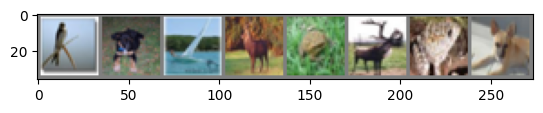

['bird', 'dog', 'ship', 'deer', 'frog', 'deer', 'frog', 'dog']


In [63]:
# Visualizar imágenes aleatorias de ejemplo del dataset
def imshow(img):
    img = img / 2 + 0.5  # desnormalizar
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

num_images = 8
indices = random.sample(range(len(train_dataset)), num_images)

images = [train_dataset[i][0] for i in indices]
labels = [train_dataset[i][1] for i in indices]

images_tensor = torch.stack(images)

imshow(torchvision.utils.make_grid(images_tensor))
print([classes[label] for label in labels])

## Definir 3 Redes Neuronales Convolucionales

In [64]:
# Función de pérdida
loss_fn = nn.CrossEntropyLoss()

# Modelo 1
model_1 = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),
    nn.Linear(32 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

# Modelo 2
model_2 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 10)
)

# Modelo 3
model_3 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 10)
)

# Optimizadores
optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=0.001)
optimizer_2 = torch.optim.Adam(model_2.parameters(), lr=0.001)
optimizer_3 = torch.optim.Adam(model_3.parameters(), lr=0.001)

# Número de épocas
num_epochs = 10

## Entrenamiento de los 3 modelos

In [65]:
# Funcion para evaluar el modelo
def evaluate(model, dataloader, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy


# Funcion para entrenar un batch
def train_batch(model, X_batch, y_batch, optimizer, loss_fn):
    # Forward pass
    predictions = model(X_batch)
    loss = loss_fn(predictions, y_batch)

    # Backward pass
    optimizer.zero_grad() 
    loss.backward() 
    optimizer.step()

    return loss.item()


# Funcion de entrenamiento completo para un modelo
def train_function(model, train_loader, test_loader, optimizer, loss_fn, num_epochs):
    
    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0

        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            loss = train_batch(model, X_batch, y_batch, optimizer, loss_fn)

            # calcular loss del batch para promedio
            running_loss += loss

        # promedio de pérdida en entrenamiento
        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)

        # evaluación en test
        test_loss, test_acc = evaluate(model, test_loader, loss_fn)
        test_losses.append(test_loss)

        print(f"Epoch {epoch+1}:")
        print(f"  Train Loss: {epoch_train_loss:.4f}")
        print(f"  Test  Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    return train_losses, test_losses

In [66]:
train_losses_1, test_losses_1 = train_function(
    model_1, train_loader, test_loader, optimizer_1, loss_fn, num_epochs
)

Epoch 1/10:  63%|██████▎   | 493/782 [00:16<00:09, 30.50it/s]


KeyboardInterrupt: 

In [ ]:
train_losses_2, test_losses_2 = train_function(
    model_2, train_loader, test_loader, optimizer_2, loss_fn, num_epochs
)

In [ ]:
train_losses_3, test_losses_3 = train_function(
    model_3, train_loader, test_loader, optimizer_3, loss_fn, num_epochs
)

In [ ]:
# Mostrar curvas de aprendizaje de los 3 modelos

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(18,5))

# Modelo 1
plt.subplot(1, 3, 1)
plt.plot(epochs, train_losses_1, label="Train Loss")
plt.plot(epochs, test_losses_1, label="Test Loss")
plt.title("Modelo 1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Modelo 2
plt.subplot(1, 3, 2)
plt.plot(epochs, train_losses_2, label="Train Loss")
plt.plot(epochs, test_losses_2, label="Test Loss")
plt.title("Modelo 2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Modelo 3
plt.subplot(1, 3, 3)
plt.plot(epochs, train_losses_3, label="Train Loss")
plt.plot(epochs, test_losses_3, label="Test Loss")
plt.title("Modelo 3")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Evaluación del mejor modelo

In [ ]:
# Mostrar evaluacion de los tres modelos 

results = []

for i, model in enumerate([model_1, model_2, model_3], start=1):
    train_loss, train_acc = evaluate(model, train_loader, loss_fn)
    test_loss, test_acc = evaluate(model, test_loader, loss_fn)

    results.append({
        "Modelo": f"Modelo {i}",
        "Train Loss": train_loss,
        "Test Loss": test_loss,
        "Train Acc": train_acc,
        "Test Acc": test_acc
    })

df_results = pd.DataFrame(results)
df_results

In [ ]:
# Seleccionar y evaluar el mejor modelo

best_model = model_2

_, test_acc = evaluate(best_model, test_loader, loss_fn)

print(f"Accuracy en test del mejor modelo: {test_acc:.4f}")

## Puntos extra: Función para clasificar imagen arbitraria

In [ ]:
# Función para usar el modelo para una imagen arbitraria
def predict_image(image_path, model=best_model, classes=classes):
    model.eval()

    # Transformación de la imagen
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5),
                             (0.5, 0.5, 0.5))
    ])

    # Cargar imagen original
    original_image = Image.open(image_path).convert("RGB")

    # Aplicar transformación
    processed_image = transform(original_image)

    # Agregar dimensión batch (formato esperado por el modelo CNN, predice batches)
    input_image = processed_image.unsqueeze(0) 

    # Predicción
    with torch.no_grad():
        outputs = model(input_image)
        _, predicted = torch.max(outputs, 1)
        predicted_class = classes[predicted.item()]

    # Mostrar imágenes
    plt.figure(figsize=(8,4))

    # Mostrar imagen original
    plt.subplot(1,2,1)
    plt.imshow(original_image)
    plt.title("Original")
    plt.axis('off')

    # Mostrar imagen escalada (desnormalizada)
    img = processed_image * 0.5 + 0.5
    npimg = img.numpy().transpose((1,2,0))

    plt.subplot(1,2,2)
    plt.imshow(npimg)
    plt.title("Procesada (32x32)")
    plt.axis('off')

    plt.show()

    print(f"Clase predicha: {predicted_class}")

In [ ]:
# Probar la función con imagen arbitraria
img_path = data_path + "imagen_prueba.jpg"

predict_image(img_path)

NameError: name 'predict_image' is not defined

## Reflexiones personales